In [ ]:
from bamboo_hh.variables import REG 
from llr_study.utils import parse_UL_results_files, create_UL_scatter_plot_by_type, plot_greedy_chain

import numpy as np
import matplotlib.pyplot as plt
import mplhep
from pathlib import Path
import pandas as pd

In [3]:
%config InlineBackend.figure_format = 'retina'

In [11]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
crtd_dirs = [d for d in projectdir.iterdir() if d.is_dir and '_crtd_odd_' in d.name]
print(f'There are {len(crtd_dirs)} total dirs')
avail_dirs, bad_dirs = [], []
for d in crtd_dirs:
    results_file = d / 'fits_new' / 'summary_results.txt'
    if results_file.exists():
        avail_dirs.append(d)
    else:
        bad_dirs.append(d)
print(f'There are {len(avail_dirs)} dirs with final results')
# ---------------------
if len(bad_dirs) > 0: 
    print(f'There are {len(bad_dirs)} dirs without final results')
    for d in bad_dirs: print(str(d)) 

There are 99 total dirs
There are 89 dirs with final results
There are 10 dirs without final results
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b14
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b15
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b2
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b3
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b4
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b5
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b6
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b7
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b8
/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd_cmb9_b9


In [5]:
file_paths = [wd / 'fits_new' / 'summary_results.txt' for wd in avail_dirs]
df = parse_UL_results_files(file_paths)
df


Total observables parsed: 52679
llr_from_multivar    52679
Name: obs_type, dtype: int64


,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,196.2,136.3,281.5,98.51,386.2,llr_from_multivar,8
1,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,196.2,136.3,281.5,98.51,383.7,llr_from_multivar,8
2,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,196.6,136.6,282.1,98.70,386.9,llr_from_multivar,8
3,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,197.2,138.9,281.4,102.10,382.1,llr_from_multivar,10
4,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,197.9,139.4,280.8,102.40,382.4,llr_from_multivar,10
...,...,...,...,...,...,...,...,...
52674,met_pt_x_blnu_mT_llr,1912.0,1369.0,2697.0,1027.00,3635.0,llr_from_multivar,2
52675,blnu_mT_x_all_jets_HT_llr,1994.0,1428.0,2812.0,1071.00,3815.0,llr_from_multivar,2
52676,blnu_mT_x_all_sT_x_all_jets_HT_llr,2102.0,1505.0,2965.0,1129.00,4022.0,llr_from_multivar,3
52677,blnu_mT_x_all_sT_llr,2288.0,1638.0,3227.0,1229.00,4377.0,llr_from_multivar,2


In [48]:
df_from_1D = parse_UL_results_files([projectdir / 'LLR_crtd_odd' / 'fits_new' / 'summary_results.txt'])
df_from_1D = df_from_1D[df_from_1D['obs_type'] == 'llr_from_1D']
df_from_1D


Total observables parsed: 686
llr_from_3D    514
llr_from_2D    120
llr_from_1D     52
Name: obs_type, dtype: int64


,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
10,jj_l_dR_llr,423.2,304.1,590.3,229.0,789.0,llr_from_1D,1
12,jj_lnu_dR_llr,432.8,310.9,603.5,234.1,806.7,llr_from_1D,1
34,WW_mInv_llr,542.9,388.8,761.4,291.6,1022.0,llr_from_1D,1
41,jj_lnu_dPhi_llr,554.5,398.4,773.3,300.0,1034.0,llr_from_1D,1
52,bjets_pt_bb_llr,582.8,418.7,812.7,315.3,1086.0,llr_from_1D,1
61,jj_l_dPhi_llr,593.8,427.7,828.1,321.2,1107.0,llr_from_1D,1
83,bjets_dR_llr,665.2,478.0,927.8,359.9,1240.0,llr_from_1D,1
103,min_b_l_dR_llr,749.8,538.7,1046.0,405.6,1398.0,llr_from_1D,1
115,trijet_bijet_dPhi_llr,783.9,563.3,1093.0,424.1,1471.0,llr_from_1D,1
122,trijet_pt_rat_llr,819.9,589.1,1143.0,443.6,1528.0,llr_from_1D,1


In [49]:
df_full = pd.concat([df, df_from_1D])
df_full

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,197.2,138.9,281.4,102.1,382.1,llr_from_multivar,10
1,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,197.9,139.4,280.8,102.4,382.4,llr_from_multivar,10
2,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,199.2,138.4,285.8,100.0,392.1,llr_from_multivar,7
3,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,199.8,141.2,283.4,104.2,386.0,llr_from_multivar,11
4,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjet_b...,200.2,141.0,285.7,103.6,387.9,llr_from_multivar,7
...,...,...,...,...,...,...,...,...
681,ak4_jet2_pt_llr,4000.0,3212.0,6392.0,2398.0,8804.0,llr_from_1D,1
682,ak4_jet2_bscore_llr,4000.0,3541.0,7093.0,2633.0,9826.0,llr_from_1D,1
683,ak4_jet1_bscore_llr,4000.0,2989.0,6025.0,2227.0,8303.0,llr_from_1D,1
684,ak4_jet3_bscore_llr,4000.0,3252.0,6551.0,2430.0,9050.0,llr_from_1D,1


LLR coverage by size: {1: 52, 2: 120, 3: 560, 4: 1820, 5: 3668, 6: 8008, 7: 3500, 10: 8008, 11: 4368, 12: 1820, 13: 560, 14: 120, 15: 16, 16: 1}
Start: jj_l_dR  μ=423.2
No valid 2-term unions found that include the start term. Check name normalization.
Greedy stop: no valid unions for the next size.
Building fallback best-by-n chain for display…


,n_terms,mu,added,combo_name,terms
0,1,423.2,jj_l_dR,jj_l_dR,"(jj_l_dR,)"
1,2,338.0,NaN,bjets_pt_bb_x_jj_lnu_dPhi,"(bjets_pt_bb, jj_lnu_dPhi)"
2,3,227.2,NaN,bjets_mbb_x_bjets_pt_bb_x_jj_lnu_dPhi,"(bjets_mbb, bjets_pt_bb, jj_lnu_dPhi)"
3,4,215.9,NaN,bjets_mbb_x_bjets_pt_bb_x_jj_lnu_dPhi_x_met_pt,"(bjets_mbb, bjets_pt_bb, jj_lnu_dPhi, met_pt)"
4,5,208.2,NaN,all_sT_x_bjets_mbb_x_bjets_pt_bb_x_jj_lnu_dPhi...,"(all_sT, bjets_mbb, bjets_pt_bb, jj_lnu_dPhi, ..."
5,6,204.6,NaN,all_sT_x_bb_lnu_dR_x_bjets_dPhi_x_bjets_mbb_x_...,"(all_sT, bb_lnu_dR, bjets_dPhi, bjets_mbb, bje..."
6,7,199.2,NaN,all_sT_x_bjet_bijet_dR_x_bjets_dPhi_x_bjets_mb...,"(all_sT, bjet_bijet_dR, bjets_dPhi, bjets_mbb,..."
7,10,197.2,NaN,all_sT_x_bb_lnu_dR_x_bjet_bijet_dR_x_bjets_dEt...,"(all_sT, bb_lnu_dR, bjet_bijet_dR, bjets_dEta,..."
8,11,199.8,NaN,all_jets_HT_x_all_sT_x_bb_lnu_dR_x_bjet_bijet_...,"(all_jets_HT, all_sT, bb_lnu_dR, bjet_bijet_dR..."
9,12,204.2,NaN,all_sT_x_bb_lnu_dR_x_bjet_bijet_dR_x_bjets_dEt...,"(all_sT, bb_lnu_dR, bjet_bijet_dR, bjets_dEta,..."


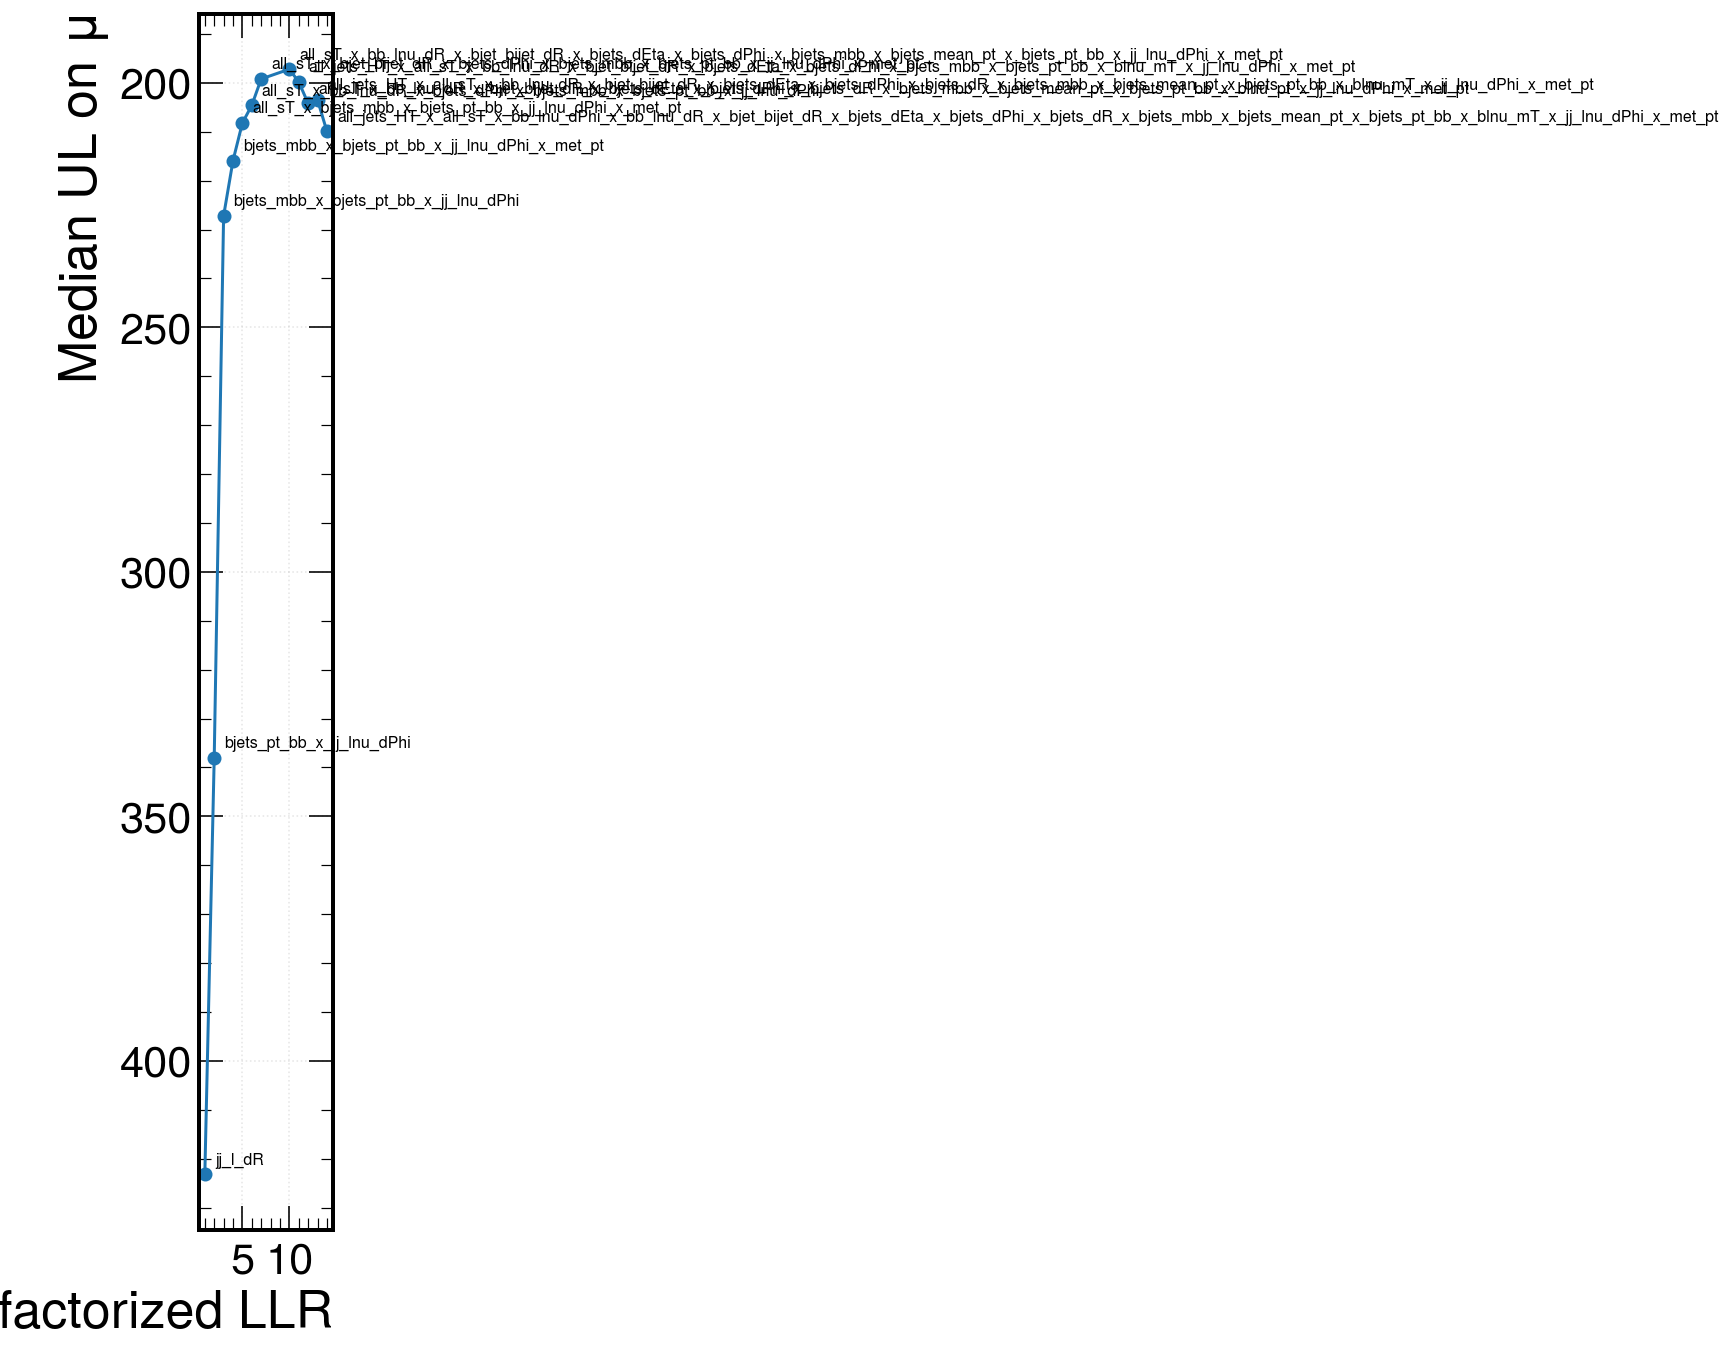

In [50]:
# --- DIAGNOSTICS + ROBUST CHAIN ---
# ----------------------------
# Helpers: parsing & lookups
# ----------------------------
def _split_terms(obs_name: str):
    """
    Convert an obs_name into an ordered tuple of base terms.
    - Multi-var: 'a_x_b_x_c' -> ('a','b','c')
    - 1D: strip trailing '_llr' if present: 'm_bb_llr' -> ('m_bb',)
    """
    if "_x_" in obs_name:
        parts = tuple(obs_name.split("_x_"))
    else:
        parts = (obs_name,)
    parts = tuple(p[:-4] if p.endswith("_llr") else p for p in parts)
    return tuple(parts)

def build_mu_lookup(df_full: pd.DataFrame):
    """
    Build two dictionaries:
      - mu_lookup: frozenset(terms) -> best mu (float)
      - name_lookup: frozenset(terms) -> representative obs_name (str)
    Uses both 'llr_from_1D' and 'llr_from_multivar' rows.
    If multiple rows map to the same set, keeps the one with the lowest mu.
    """
    mu_lookup = {}
    name_lookup = {}

    df_use = df_full[df_full["obs_type"].isin(["llr_from_1D", "llr_from_multivar"])].copy()
    for _, row in df_use.iterrows():
        terms = _split_terms(row["obs_name"])
        key = frozenset(terms)
        mu = float(row["mu"])
        if (key not in mu_lookup) or (mu < mu_lookup[key]):
            mu_lookup[key] = mu
            # normalize name to a stable order for pretty printing
            name_lookup[key] = "_x_".join(sorted(terms))
    return mu_lookup, name_lookup

def summarize_coverage(mu_lookup):
    from collections import Counter
    sizes = Counter(len(k) for k in mu_lookup.keys())
    print("LLR coverage by size:", dict(sorted(sizes.items())))

def best_candidate_from(current_set, pool_terms, mu_lookup):
    """
    Among all pool terms not in current_set, return the best union
    (key, mu, added_term). Returns (None, inf, None) if no union found.
    """
    import math
    best_key, best_mu, best_added = None, math.inf, None
    for cand in pool_terms:
        if cand in current_set:
            continue
        key = frozenset(current_set | {cand})
        mu = mu_lookup.get(key, math.inf)
        if mu < best_mu:
            best_key, best_mu, best_added = key, mu, cand
    return best_key, best_mu, best_added

def greedy_chain_debug(df_full, pool_terms=None, min_improve_frac=0.01, max_terms=8, start_term=None):
    mu_lookup, name_lookup = build_mu_lookup(df_full)
    summarize_coverage(mu_lookup)

    # default pool = all singles present in mu_lookup
    if pool_terms is None:
        singles = [k for k in mu_lookup.keys() if len(k) == 1]
        pool_terms = sorted({next(iter(s)) for s in singles})

    # choose start (best single in pool unless provided)
    if start_term is None:
        cur = min((frozenset([t]) for t in pool_terms if frozenset([t]) in mu_lookup),
                  key=lambda k: mu_lookup[k])
    else:
        cur = frozenset([start_term])
        assert cur in mu_lookup, f"Start term '{start_term}' not found."

    rows = [{
        "n_terms": 1,
        "mu": mu_lookup[cur],
        "added": next(iter(cur)),
        "combo_name": name_lookup[cur],
        "terms": tuple(sorted(cur))
    }]
    print(f"Start: {rows[-1]['combo_name']}  μ={rows[-1]['mu']:.1f}")

    # one step of candidate scan (diagnostic printout)
    key, mu_cand, added = best_candidate_from(set(cur), pool_terms, mu_lookup)
    if key is None or not np.isfinite(mu_cand):
        print("No valid 2-term unions found that include the start term. Check name normalization.")
    else:
        gain = (rows[-1]['mu'] - mu_cand)/rows[-1]['mu']
        print(f"Best 2-term expansion: add '{added}' → μ={mu_cand:.1f}  (rel. gain {100*gain:.1f}%)")

    # proceed with greedy
    current_mu = rows[-1]['mu']
    while len(cur) < max_terms:
        key, mu_cand, added = best_candidate_from(set(cur), pool_terms, mu_lookup)
        if key is None or not np.isfinite(mu_cand):
            print("Greedy stop: no valid unions for the next size.")
            break
        frac = (current_mu - mu_cand)/current_mu if current_mu > 0 else 0.0
        if frac < min_improve_frac:
            print(f"Greedy stop: best gain {100*frac:.2f}% < {100*min_improve_frac:.2f}% threshold.")
            break
        # accept
        cur = key
        current_mu = mu_cand
        rows.append({
            "n_terms": len(cur),
            "mu": current_mu,
            "added": added,
            "combo_name": name_lookup[cur],
            "terms": tuple(sorted(cur))
        })
        print(f"Add '{added}': μ={current_mu:.1f}")

    chain_df = pd.DataFrame(rows)

    # ---------- Fallback: best-by-n chain ----------
    # If greedy produced only one point, build a “best-by-n” path for plotting
    if len(chain_df) == 1:
        print("Building fallback best-by-n chain for display…")
        # group mu_lookup by size and pick the best at each size
        records = []
        for k, mu in mu_lookup.items():
            n = len(k)
            if n <= max_terms and all(t in pool_terms for t in k):
                records.append((n, mu, name_lookup[k], tuple(sorted(k))))
        best_by_n = (pd.DataFrame(records, columns=["n_terms","mu","combo_name","terms"])
                     .sort_values(["n_terms","mu"])
                     .groupby("n_terms", as_index=False)
                     .first()
                     .sort_values("n_terms"))
        # keep only sizes >= current size
        best_by_n = best_by_n[best_by_n["n_terms"] >= chain_df["n_terms"].iloc[0]]
        chain_df = pd.concat([chain_df, best_by_n.iloc[1:]], ignore_index=True)

    return chain_df

# --- run & plot ---
chain = greedy_chain_debug(
    df_full,
    pool_terms=None,          # or your curated list of 14/16 base terms
    min_improve_frac=0.01,    # try 0.0 or 0.005 if you want ultra-permissive
    max_terms=14,
    start_term=None
)


# Plot (invert y so “down is better”)
plt.figure(figsize=(12,10))
plt.plot(chain["n_terms"], chain["mu"], marker="o")
for _, r in chain.iterrows():
    plt.annotate(r["combo_name"], (r["n_terms"], r["mu"]), xytext=(5,5),
                 textcoords="offset points", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("# of terms in factorized LLR")
plt.ylabel("Median UL on $\\mu$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("factorized_greedy_chain.pdf", dpi=300)
chain


In [14]:
df_full

,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
0,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,197.2,138.9,281.4,102.1,382.1,llr_from_multivar,10
1,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,197.9,139.4,280.8,102.4,382.4,llr_from_multivar,10
2,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,199.2,138.4,285.8,100.0,392.1,llr_from_multivar,7
3,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,199.8,141.2,283.4,104.2,386.0,llr_from_multivar,11
4,jj_lnu_dPhi_x_bjets_pt_bb_x_bjets_mbb_x_bjets_...,200.2,141.4,284.1,103.6,386.9,llr_from_multivar,7
...,...,...,...,...,...,...,...,...
681,ak4_jet2_pt_llr,4000.0,3212.0,6392.0,2398.0,8804.0,llr_from_1D,1
682,ak4_jet2_bscore_llr,4000.0,3541.0,7093.0,2633.0,9826.0,llr_from_1D,1
683,ak4_jet1_bscore_llr,4000.0,2989.0,6025.0,2227.0,8303.0,llr_from_1D,1
684,ak4_jet3_bscore_llr,4000.0,3252.0,6551.0,2430.0,9050.0,llr_from_1D,1


In [42]:
def this_create_UL_scatter_plot_by_type(df: pd.DataFrame, outfile):
    import mplhep
    import matplotlib.patches as patches
    from matplotlib.collections import LineCollection
    import numpy as np
    
    mplhep.style.use("CMS")
    
    label_fontsize = 26
    tick_fontsize = 26
    cms_fontsize = 26
    
    # Create figure with CMS-like styling
    fig, ax = plt.subplots(figsize=(20, 12))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    x_positions = []
    y_values = []
    colors = []
    labels = []
    categories = []
    
    current_x = 1
    
    # Enhanced color palette
    type_mapping = {
        'llr_from_1D': ('Univariate LLR', '#e74c3c', '#c0392b'),
        'llr_from_2D': ('Bivariate LLR', '#3498db', '#2980b9'), 
        'llr_from_3D': ('Trivariate LLR', '#2ecc71', '#27ae60')
    }
    
    # Add continuous background regions - all exactly 1.0 unit wide, no gaps
    region_colors = ['#ffeaea', '#eaf4ff', '#eafff0']
    region_index = 0
    region_boundaries = []
    
    for obs_type, (label, color_main, color_dark) in type_mapping.items():
        subset = df[df['obs_type'] == obs_type]
        if not subset.empty:
            # All regions exactly 1.0 unit wide: center ± 0.5
            start_x = current_x - 0.5
            end_x = current_x + 0.5
            
            # Add subtle background coloring
            ax.axvspan(start_x, end_x, 
                      facecolor=region_colors[region_index], alpha=0.3, zorder=0)
            
            # Store boundary for dividing lines (except for first region)
            if current_x > 1:
                region_boundaries.append(start_x)
            
            region_index += 1
            
            # Create gradient effect with multiple layers
            x_jitter = np.random.normal(current_x, 0.08, len(subset))
            
            # Add glow effect (larger, more transparent points behind)
            ax.scatter(x_jitter, subset['mu'], c=color_main, s=120, alpha=0.3, 
                      edgecolors='none', zorder=1)
            
            # Main points with gradient coloring based on y-value
            scatter = ax.scatter(x_jitter, subset['mu'], c=subset['mu'], 
                               cmap='viridis', s=80, alpha=0.8,
                               edgecolors=color_dark, linewidth=1.2, zorder=3)
            
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu'].tolist())  # Convert to list explicitly
            colors.extend([color_main] * len(subset))
            labels.append(label)
            categories.extend([label] * len(subset))
            current_x += 1
    
    # Enhanced multivariate section
    multivar_df = df[df['obs_type'] == 'llr_from_multivar']
    if not multivar_df.empty:
        n_var_values = sorted(multivar_df['n_variables'].unique())
        
        # Custom gradient colors for multivariate
        plasma_colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(n_var_values)))
        
        multivar_names = {
            2: '2', 3: '3', 4: '4', 5: '5',
            6: '6', 7: '7', 8: '8', 9: '9',
            10: '10', 11: '11', 12: '12', 13: '13',
            14: '14', 15: '15', 16: '16'
        }
        
        # Add individual background regions for each multivariate category
        multivar_region_colors = plt.cm.plasma(np.linspace(0.05, 0.15, len(n_var_values)))
        
        for i, n_vars in enumerate(n_var_values):
            # Individual background region for each multivariate category
            x_center = current_x + i
            start_x = x_center - 0.5
            end_x = x_center + 0.5
            ax.axvspan(start_x, end_x, 
                      facecolor=multivar_region_colors[i], alpha=0.2, zorder=0)
            
            # Add boundary for dividing lines between multivariate categories
            if i > 0:  # Add boundary between multivariate categories
                region_boundaries.append(start_x)
            elif current_x > 1:  # Add boundary before first multivariate if there were previous categories
                region_boundaries.append(start_x)
        
        # Plot the actual data points
        for i, n_vars in enumerate(n_var_values):
            subset = multivar_df[multivar_df['n_variables'] == n_vars]
            
            # Use the correct x position for each category
            x_center = current_x + i
            
            # Smaller jitter for cleaner look
            x_jitter = np.random.normal(x_center, 0.06, len(subset))
            
            # Glow effect (same as other LLR types)
            ax.scatter(x_jitter, subset['mu'], c=plasma_colors[i], s=120, alpha=0.3,
                      edgecolors='none', zorder=1)
            
            # Main scatter with gradient coloring (same as other LLR types)
            scatter = ax.scatter(x_jitter, subset['mu'], c=subset['mu'], 
                               cmap='viridis', s=80, alpha=0.8,
                               edgecolors=plasma_colors[i], linewidth=1.2, zorder=3)
            
            x_positions.extend(x_jitter)
            y_values.extend(subset['mu'].tolist())  # Convert to list explicitly
            colors.extend([plasma_colors[i]] * len(subset))
            labels.append(multivar_names.get(n_vars, f"Multi-{n_vars}"))
            categories.extend([f"{n_vars}"] * len(subset))
    
    # Check if we have any data to plot
    if not y_values:
        print("No data to plot!")
        return
    
    # Add subtle vertical dividing lines between all regions
    for boundary_x in region_boundaries:
        ax.axvline(boundary_x, color='#cccccc', alpha=0.6, linestyle='-', linewidth=1.5, zorder=2)
    
    # CMS-style grid (only horizontal, more subtle)
    ax.grid(True, alpha=0.3, axis='y', linestyle='-', linewidth=0.8, color='#cccccc')
    ax.grid(False, axis='x')
    
    # CMS-style spines - thick black borders
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color('black')
    
    # CMS-style tick parameters
    ax.tick_params(axis='x', which='major', direction='in', length=0, width=0,
                   labelsize=tick_fontsize, top=False, right=False, 
                   bottom=True, left=False, color='black')
    ax.tick_params(axis='y', which='major', direction='in', length=6, width=2,
                   labelsize=tick_fontsize, top=True, right=True, 
                   bottom=True, left=True, color='black')
    ax.tick_params(axis='y', which='minor', direction='in', length=3, width=1,
                   top=True, right=True, bottom=True, left=True, color='black')
    
    ax.tick_params(axis='x', which='minor', bottom=False, top=False)
    
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, fontsize=tick_fontsize)
    
    # CMS-style labels - updated for multivariate context
    ax.set_ylabel('Median UL on μ', fontsize=label_fontsize)
    ax.set_xlabel('Number of Variables in LLR', fontsize=label_fontsize)
    
    # Add CMS text
    mplhep.cms.text("Simulation Preliminary", ax=ax, fontsize=cms_fontsize, loc=0)
    ax.text(1.0, 1.0, "13.6 TeV", transform=ax.transAxes, fontsize=cms_fontsize,
            horizontalalignment='right', verticalalignment='bottom')
    
    plt.tight_layout()
    
    # Set limits
    ax.set_xlim(0.5, len(labels) + 0.5)
    
    # Y-axis setup
    from matplotlib.ticker import MaxNLocator
    
    y_range = max(y_values) - min(y_values) 
    y_min = 150
    y_max = max(y_values) + 0.08 * y_range
    ax.set_ylim(y_min, y_max)
    
    # Tick setup
    tick_list = [200]
    tick_candidates = np.arange(200, 4300, 400)
    tick_list.extend(tick_candidates[tick_candidates <= y_max])
    tick_list = sorted(list(set(tick_list)))
    ax.set_yticks(tick_list)
    
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style enhanced scatter plot saved to {outfile}")
    
    plt.show()

/tmp/anunezde/ipykernel_3493365/408536755.py:117: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_jitter, subset['mu'], c=plasma_colors[i], s=120, alpha=0.3,


CMS-style enhanced scatter plot saved to llr_multivar_scatterplot_UL.pdf


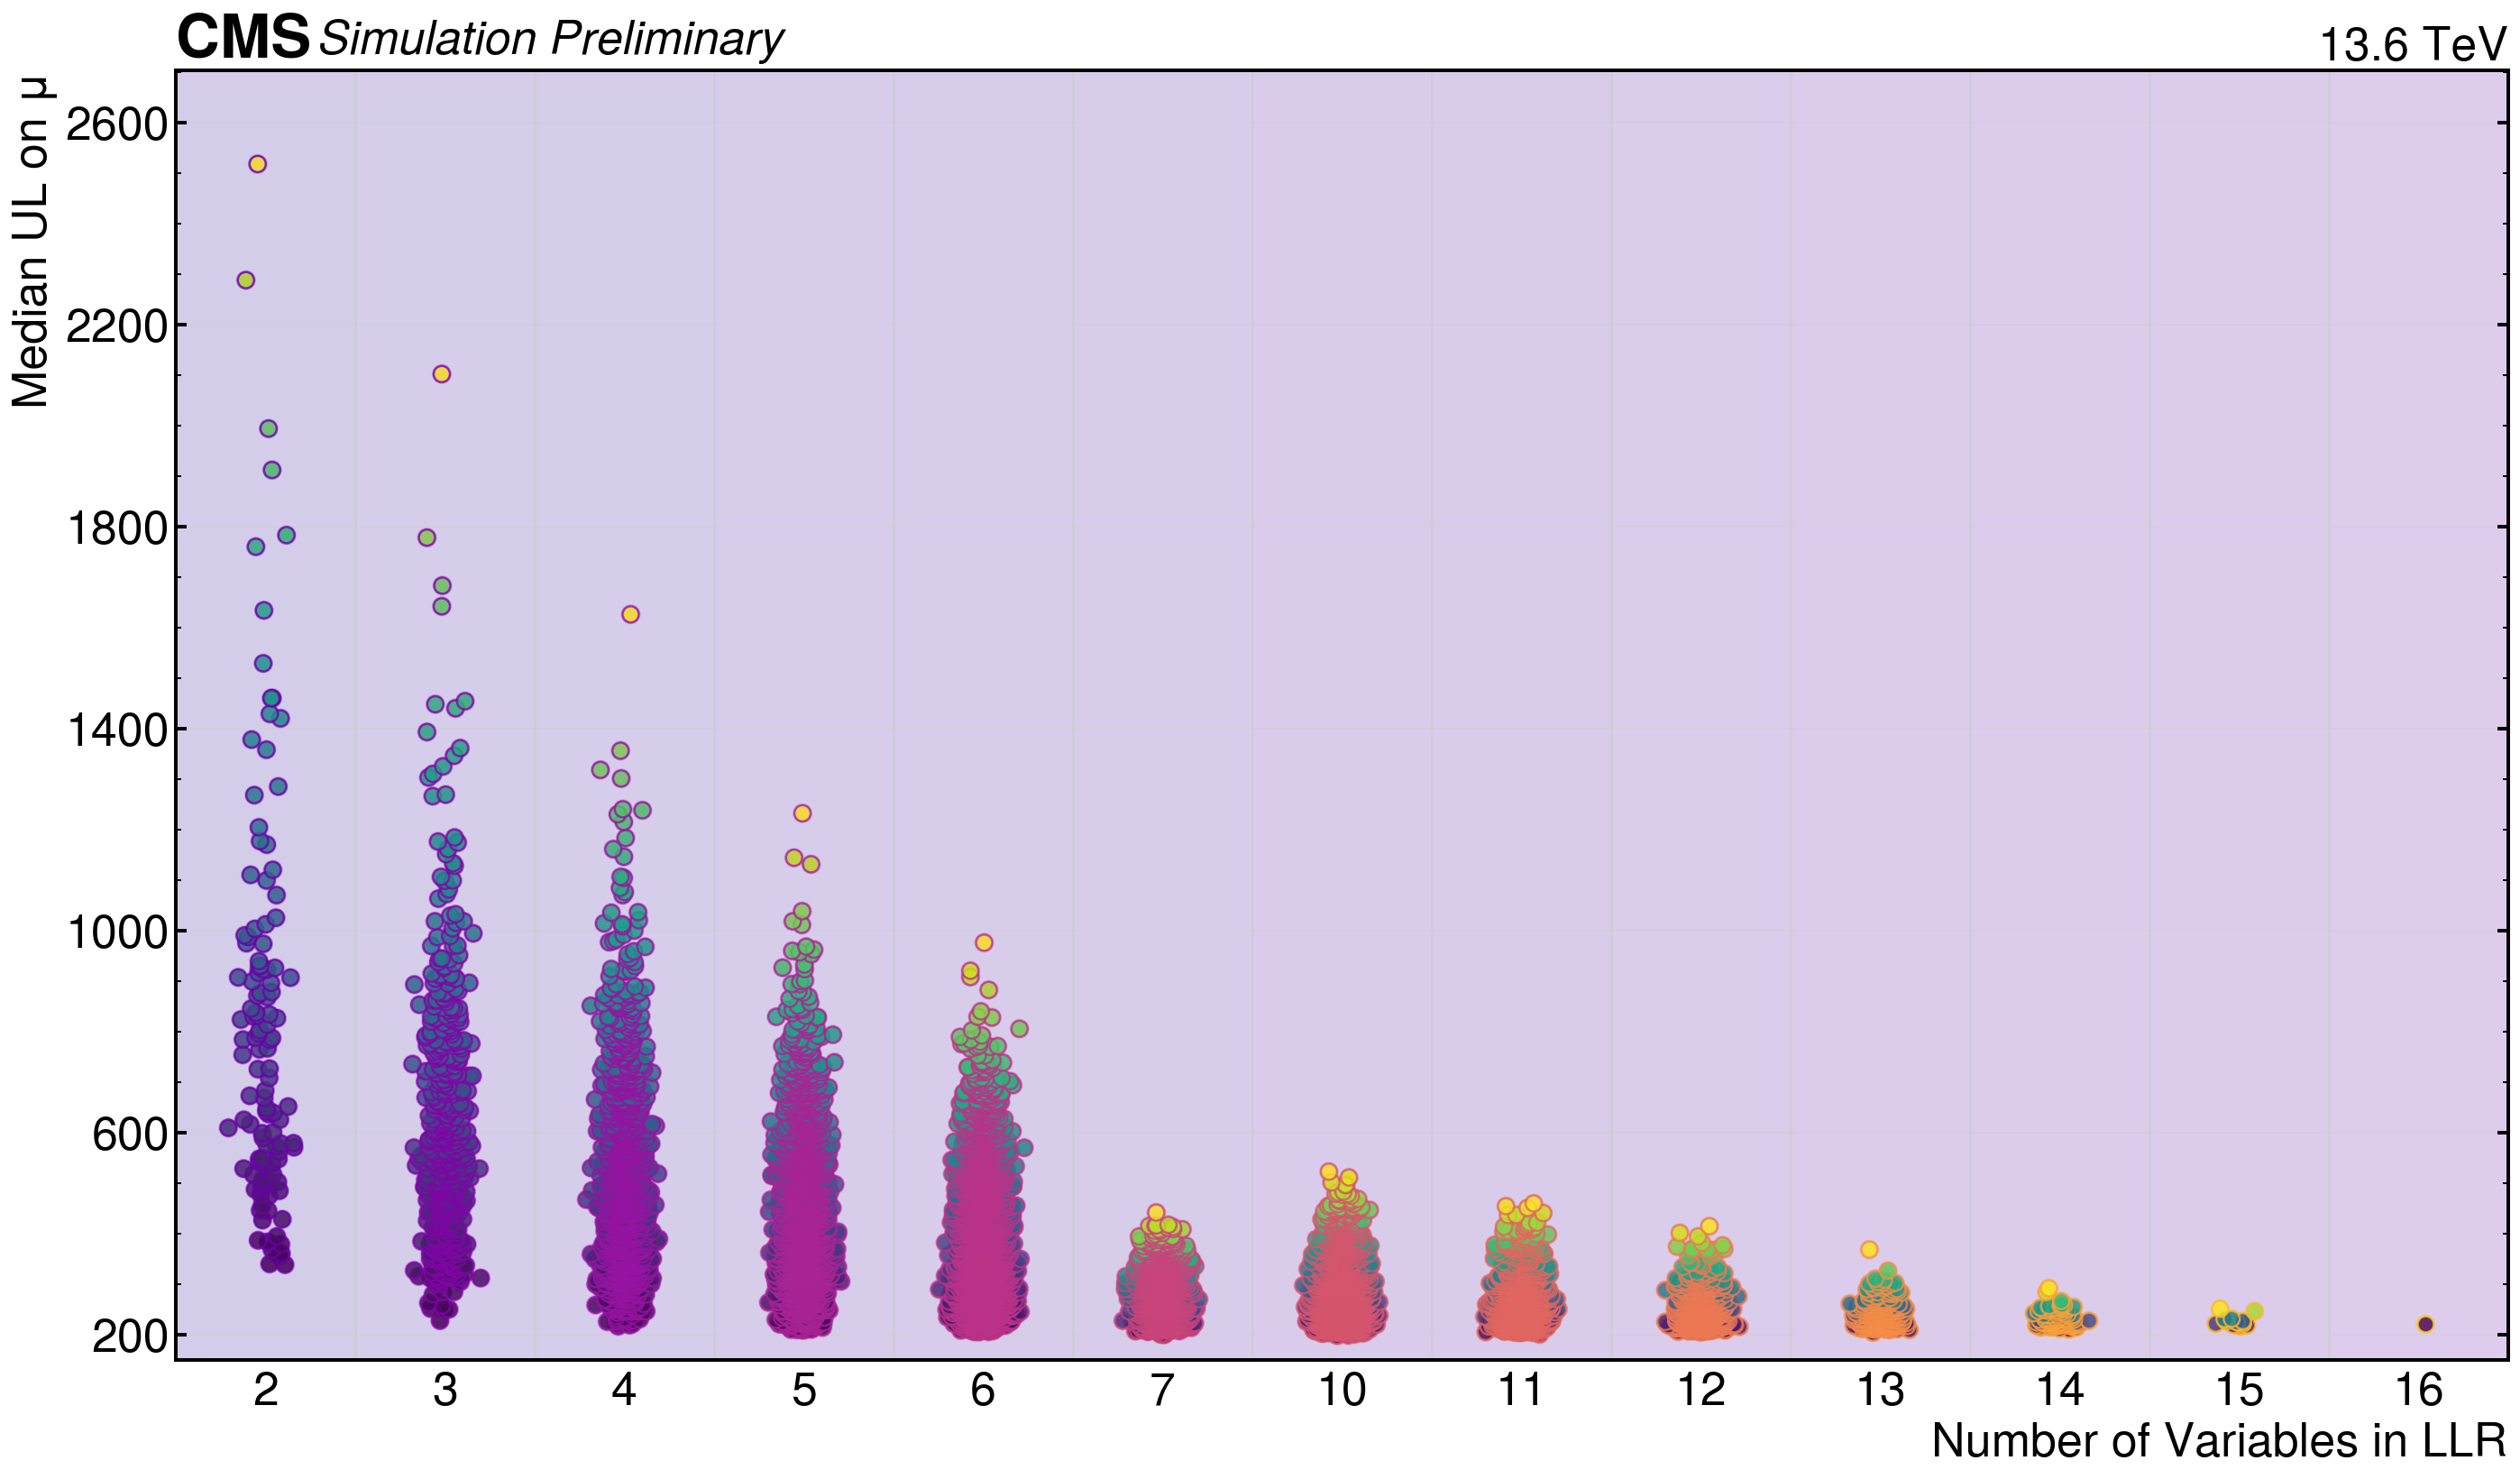

In [45]:
this_create_UL_scatter_plot_by_type(df, Path('.') / 'llr_multivar_scatterplot_UL.pdf')

/tmp/anunezde/ipykernel_3493365/408536755.py:117: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_jitter, subset['mu'], c=plasma_colors[i], s=120, alpha=0.3,


CMS-style enhanced scatter plot saved to llr_multivar_scatterplot_UL.pdf


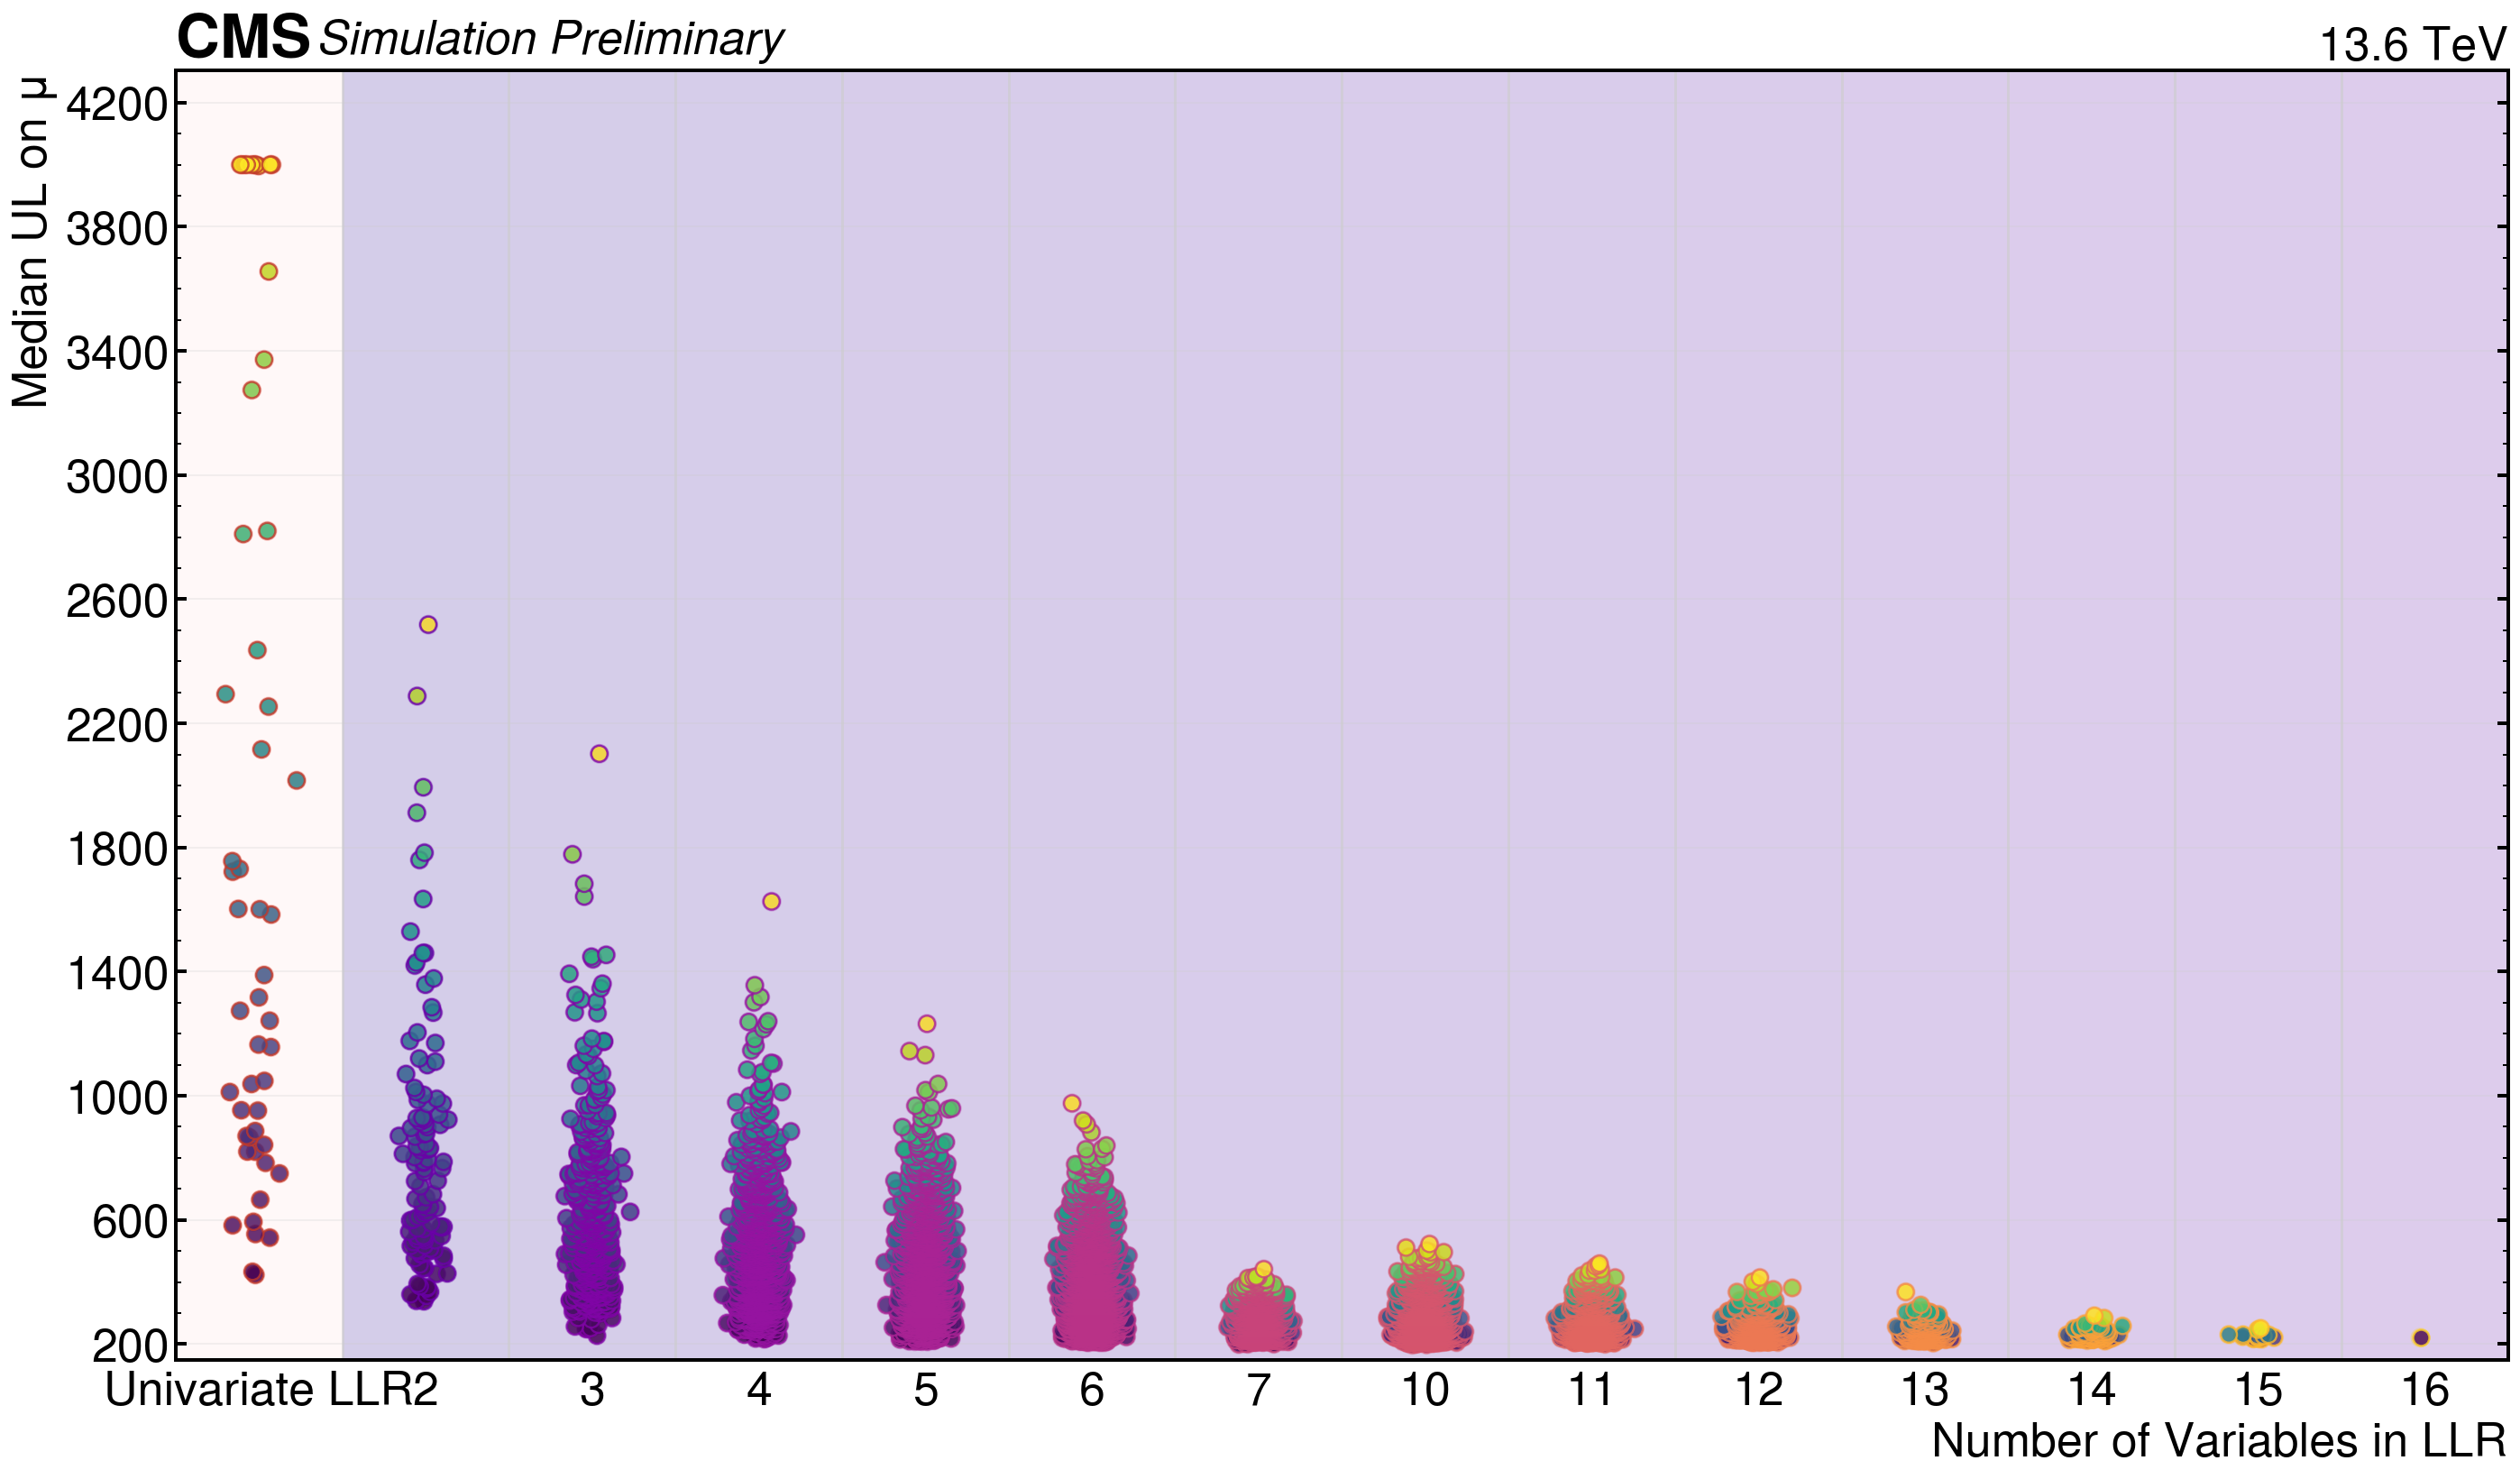

In [44]:
this_create_UL_scatter_plot_by_type(df_full, Path('.') / 'llr_multivar_scatterplot_UL.pdf')

In [ ]:
df_full.to_csv('full')